# Assignment 1: Classification
# Glass Identification Dataset

## 184.702 Machine Learning (VU 3,0) 2021W

### Group 11
Member: **András Bonifác Kónya** (Student ID: 01502933), **Branimir Raguž** (Student ID: 12123474), **Thummanoon Kunanuntakij** (Student ID: 12122522)

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import iqr
from sklearn import metrics
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, MaxAbsScaler
from sklearn.feature_selection import VarianceThreshold
from pprint import pprint
import warnings

## 1. Setup

In [15]:
RANDOM_SEED = 1234

In [16]:
def plot_params_accuracy(accuracy, xticks, height=10, width=10):
    fig, ax = plt.subplots(1, 1)
    fig.set_figheight(height)
    fig.set_figwidth(width)
    plt.sca(ax)
    plt.xticks(range(len(accuracy)), xticks)
    ax.plot(range(len(accuracy)), accuracy)
    fig.show()

## 2. Data Loading

In [17]:
if os.getcwd().split('/')[1] == 'kaggle':
    data_df = pd.read_csv('/kaggle/input/glass/glass.csv')
else:
    data_df = pd.read_csv('../data/glass/glass.csv')
if 'Id' in data_df.columns:
    data_df = data_df.drop(columns=['Id'])

## 3. Overview of the Data

The goal of this data set is to predict the type of the glass using the given features.

214 Observations

Feature list:
- RI: refractive index
- Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
- Mg: Magnesium
- Al: Aluminum
- Si: Silicon
- K: Potassium
- Ca: Calcium
- Ba: Barium
- Fe: Iron

Type of glass: (class attribute)
1. building_windows_float_processed
2. building_windows_non_float_processed
3. vehicle_windows_float_processed
4. vehicle_windows_non_float_processed (none in this database)
5. containers
6. tableware
7. headlamps

In [19]:
data_df.info()
data_df['Type'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


2    76
1    70
7    29
3    17
5    13
6     9
Name: Type, dtype: int64

## 4. Train / Test Data 
At this step, to simulate real life situation that we want to measure the performance of our model against unseen data. We split the data into modelling and testing set. We reserve the testing set to the very last step after we have chosen a model and its optimal parameters already.

We also split the modelling data into training and validation set again so we can use this for parameter tuning / model selection.

Because this dataset is small, we couldn't split for larger the testing and validation set.

In [20]:
X = data_df.drop(columns=['Type'])
y = data_df['Type']
X_model, X_test, y_model, y_test = train_test_split(X, y, test_size=0.15, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_model, y_model, test_size=0.2, random_state=RANDOM_SEED)

Our training data

In [21]:
X_train.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,1.518146,13.436875,2.732708,1.476042,72.654236,0.507083,8.805208,0.195972,0.056458
std,0.002526,0.745630,1.390950,0.509923,0.719515,0.605959,1.129206,0.499912,0.099161
min,1.511310,11.030000,0.000000,0.290000,69.890000,0.000000,5.430000,0.000000,0.000000
25%,1.516498,12.887500,2.270000,1.210000,72.275000,0.140000,8.280000,0.000000,0.000000
50%,1.517680,13.360000,3.480000,1.355000,72.765000,0.555000,8.600000,0.000000,0.000000
75%,1.519060,13.882500,3.582500,1.642500,73.085000,0.612500,9.072500,0.000000,0.090000
max,1.527770,15.790000,4.490000,3.500000,75.180000,6.210000,14.400000,2.880000,0.510000


In [22]:
y_train.value_counts()

2    50
1    46
7    24
3    13
5     6
6     5
Name: Type, dtype: int64

## 5. Data Preprocessing

### 5.1 Missing values
We could see that there are no N/A in our original dataset

In [23]:
X_model.isna().sum()

RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64

### 5.2 Outlier
From the box plot, there are no clear set of outlier in the data. The features that look like being further away from the median might be a characteristic of a certain type of data, so we should not remove them.

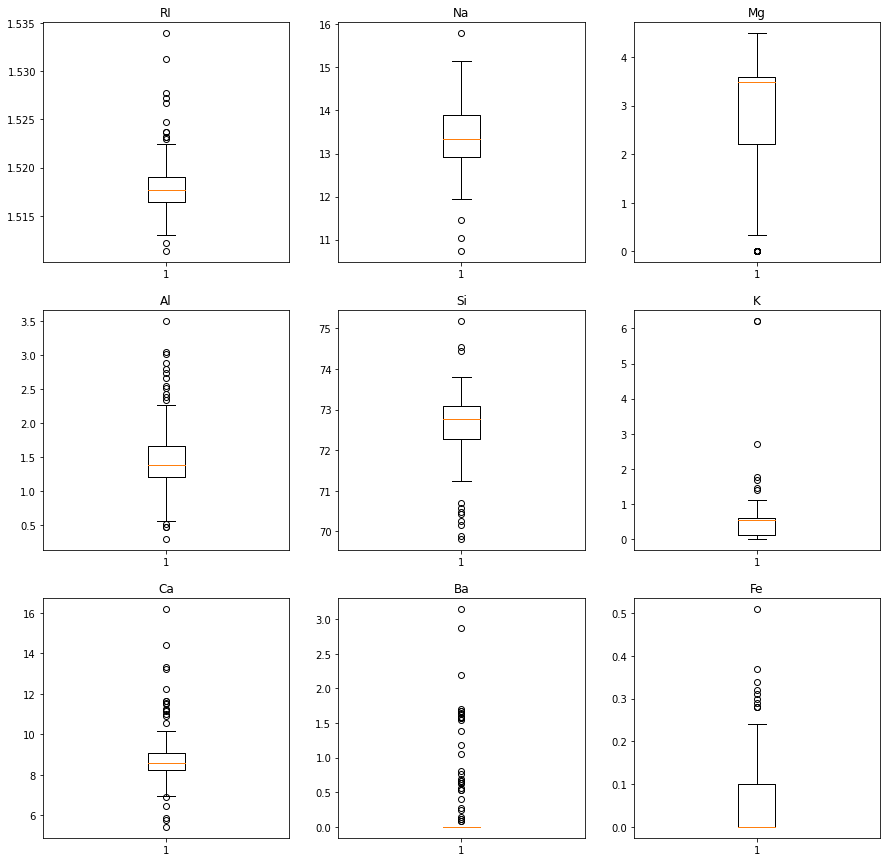

In [25]:
num_row = 3
num_col = 3
fig, ax = plt.subplots(num_col, num_row)
fig.set_figheight(15)
fig.set_figwidth(15)

for index, col in enumerate(X_model.columns):
    ax[index // num_row, index % num_row].boxplot(X_model[col])
    ax[index // num_row, index % num_row].set_title(col)


### 5.3 Feature Scaling
We could see that some parameters such as `Si`, `Ca` and `Na` are significance larger than the rest of the parameter, so feature scaling might be necessary for some algorithms.

In [133]:
X_train.describe().loc[['min', 'mean', 'max']]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
min,1.511310,11.030000,0.000000,0.290000,69.890000,0.000000,5.430000,0.000000,0.000000
mean,1.518146,13.436875,2.732708,1.476042,72.654236,0.507083,8.805208,0.195972,0.056458
max,1.527770,15.790000,4.490000,3.500000,75.180000,6.210000,14.400000,2.880000,0.510000


We could see from the histogram that most parameters look similar to a normal distribution except those that have a lot of 0. Thus, we might not need to specifically standardised the data.

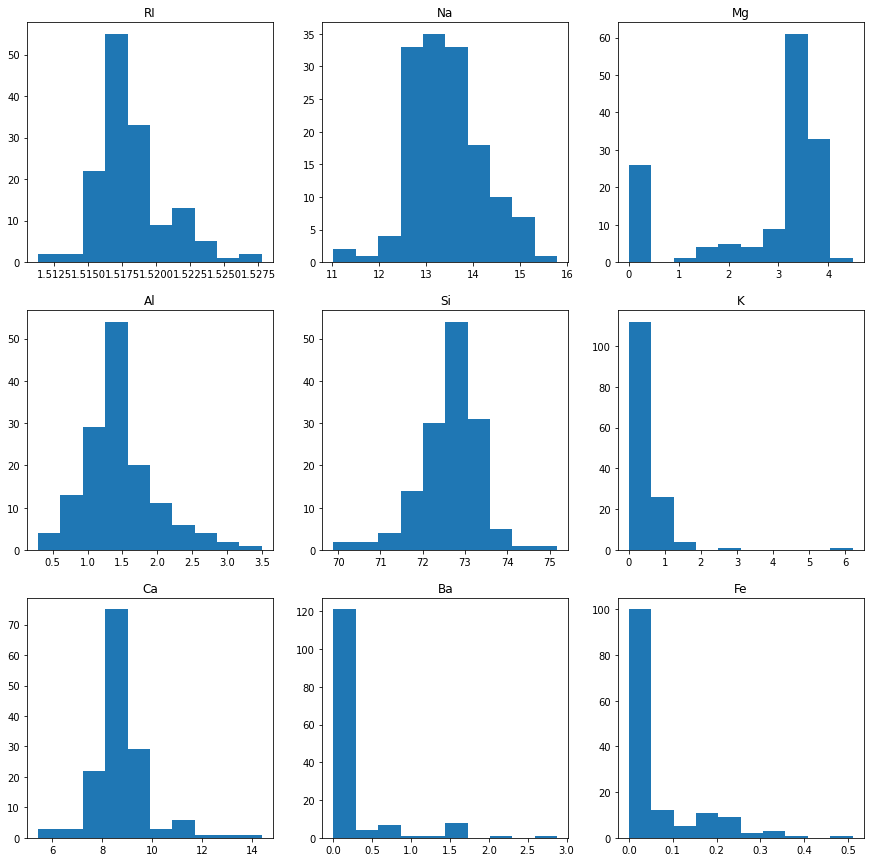

In [28]:
num_row = 3
fig, ax = plt.subplots(3, num_row)
fig.set_figheight(15)
fig.set_figwidth(15)

for index, col in enumerate(X_train.columns):
    ax[index//num_row, index%num_row].hist(X_train[col])
    ax[index//num_row, index%num_row].set_title(col)

Because each machine learning algorithms require different criteria for its input data so we would do the feature transformation later during the analysis of each model.

## 6. Evaluation Metrics

We would use mainly `Accuracy` when performing any parameter tuning. But we also include `F1 Macro` to get further insight.

##  7. Naive Baseline Model
First, we create a baseline model by predicting only the most occurance class.

In [29]:
most_occur_class = y_train.value_counts().idxmax()
baseline_predict = np.ones(len(y_val)) * most_occur_class
print(f'Accuracy of Baseline (predict with class {most_occur_class}):', metrics.accuracy_score(y_val, baseline_predict))

Accuracy of Baseline (predict with class 2): 0.40540540540540543


## 8. Model#1 Logistic Regression


In [30]:
from sklearn.linear_model import LogisticRegression

### 8.1 Default Model

In [31]:
default_logistic_regression_model = LogisticRegression(random_state=RANDOM_SEED, max_iter=10000)
score = cross_validate(default_logistic_regression_model, X_train, y_train, cv=3)
print('Mean accuracy of Logistic Regression(default)) cv:', np.mean(score['test_score']))

Mean accuracy of Logistic Regression(default)) cv: 0.6111111111111112


In [32]:
default_logistic_regression_model.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=1234)

### 8.2 Parameter Scaling
First we use various parameter scaling to find out which transformation could deliver the highest cross validation score.

In [139]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=10000))
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=3).fit(X_train, y_train)

We could see that **no scaler** and using `standardScaler()` perform similarly good.

Maximum accuracy for no scaler is 0.6111111111111112
Best model is None


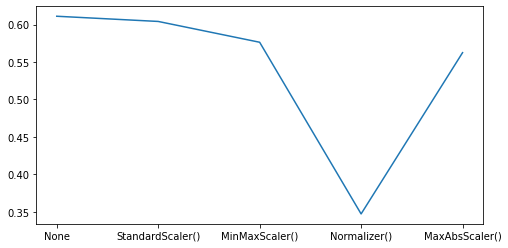

In [140]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)
print('Maximum accuracy for no scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

### 8.3 Tuning Parameter: solver / penalty
Note that we scale the data first with the best method in the previous step.

In [35]:
parameters = [
    {'solver': 'newton-cg', 'penalty': 'l2'},
    {'solver': 'newton-cg', 'penalty': 'none'},
    {'solver': 'lbfgs', 'penalty': 'l2'},
## There is a bug in the implementation so this configuration cannot be run.
#   {'solver': 'lbfgs', 'penalty': 'none'},
    {'solver': 'liblinear', 'penalty': 'l1'},
    {'solver': 'liblinear', 'penalty': 'l2'},
    {'solver': 'sag', 'penalty': 'l2'},
    {'solver': 'sag', 'penalty': 'none'},
    {'solver': 'saga', 'penalty': 'l1'},
    {'solver': 'saga', 'penalty': 'l2'},
    {'solver': 'saga', 'penalty': 'none'}
]

#### 8.3.1 Case 1: Without scaler

In [36]:
accuracy = []

for parameter in parameters:
    pipe = Pipeline([
        ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                          max_iter=10000,
                                          solver=parameter['solver'],
                                          penalty=parameter['penalty']
                                         )
        )
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=3)
    accuracy.append(np.mean(scores['test_score']))

Maximum accuracy for no scaler is 0.625
Best model is saga_none


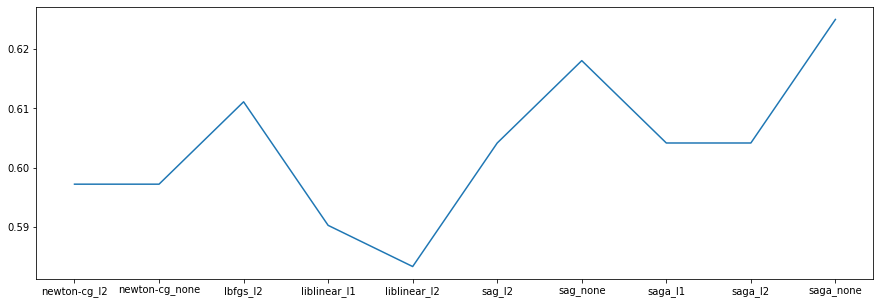

In [37]:
x_ticks = [f'{p["solver"]}_{p["penalty"]}' for p in parameters]
plot_params_accuracy(accuracy, x_ticks, height=5, width=15)
print('Maximum accuracy for no scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

#### 8.3.2 Case 2 with Standard Scaler

In [38]:
accuracy = []

for parameter in parameters:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                          max_iter=10000,
                                          solver=parameter['solver'],
                                          penalty=parameter['penalty']
                                         )
        )
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=3)
    accuracy.append(np.mean(scores['test_score']))

The best parameter are `solver="liblinear"` and `penalty="l2"`

Maximum accuracy for standard scaler is 0.6319444444444445
Best model is liblinear_l2


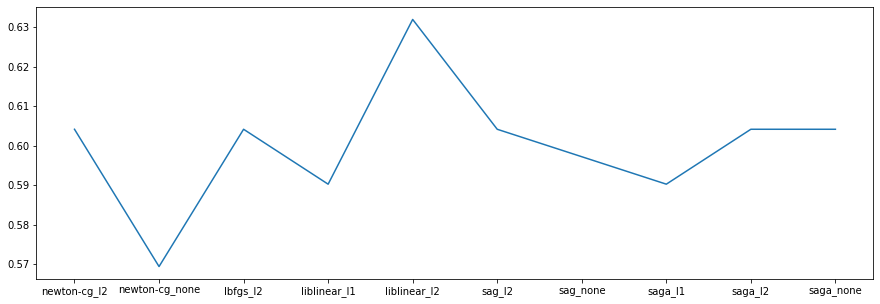

In [40]:
x_ticks = [f'{p["solver"]}_{p["penalty"]}' for p in parameters]
plot_params_accuracy(accuracy, x_ticks, height=5, width=15)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

### 8.4 Tuning Parameter: C
C is a regularized parameter. The smaller the more restrict. Because the non-scaler case has no penalty, we don't need to change anythings.

In [53]:
C = [0.1, 0.3, 1, 3, 5, 10, 13, 15, 20, 25]

In [56]:
parameters = [
    {'solver': 'liblinear', 'penalty': 'l2'}
]
accuracy = []
x_ticks = []
for parameter in parameters:
    for regularized_parameter in C:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                              max_iter=10000,
                                              solver=parameter['solver'],
                                              penalty=parameter['penalty'],
                                              C=regularized_parameter
                                             )
            )
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=3)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'{parameter["solver"]}_{parameter["penalty"]}_C={regularized_parameter}')

We could see that `solver=saga`,`penalty=l2` and `C=5` perform the best.

Maximum accuracy for standard scaler is 0.6458333333333334
Best model is liblinear_l2_C=10


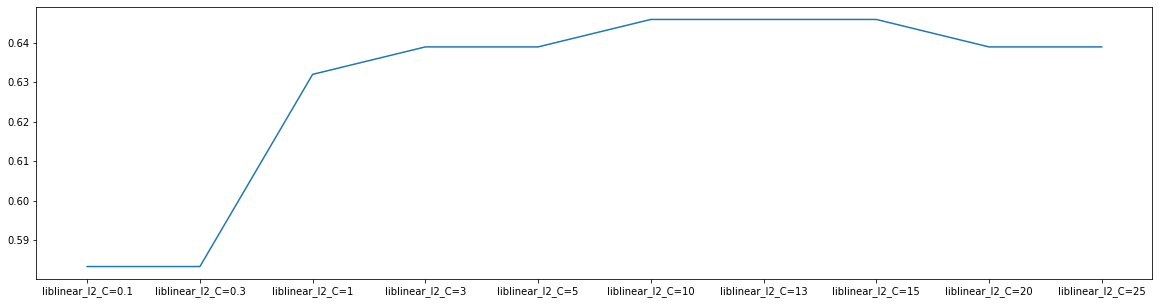

In [57]:
plot_params_accuracy(accuracy, x_ticks, height=5, width=20)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

### 8.5 Validation Set

#### 8.5.1 Default Model

In [106]:
default_regression_predict_val = default_logistic_regression_model.predict(X_val)
print('Accuracy of CV training set Logistic Regression(default)):',
      np.mean(cross_validate(default_logistic_regression_model, X_train, y_train, cv=3)['test_score']))
print('Accuracy of Validation set Logistic Regression(default)):',
      metrics.accuracy_score(y_val, default_regression_predict_val))
print('Macro F1 Score of Validation set Logistic Regression(default)):',
      metrics.f1_score(y_val, default_regression_predict_val, average='macro'))

Accuracy of CV training set Logistic Regression(default)): 0.6111111111111112
Accuracy of Validation set Logistic Regression(default)): 0.4864864864864865
Macro F1 Score of Validation set Logistic Regression(default)): 0.347979797979798


#### 8.5.2 Optimal Model

#### 8.5.2.1 Case 1: No scaler

In [107]:
optimal_logistic_regression_pipe = Pipeline([
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='saga',
                                      penalty='none'
                                     )
    )
])
scores = cross_validate(optimal_logistic_regression_pipe, X_train, y_train, cv=3)
print('optimal parameter training set score (no scaler) cv:', np.mean(scores['test_score']))
optimal_logistic_regression_pipe.fit(X_train, y_train)
optimal_logistic_regression_predict_val = optimal_logistic_regression_pipe.predict(X_val)
print('optimal parameter set score (no scaler):', metrics.accuracy_score(y_val, optimal_logistic_regression_predict_val))
print('F1 Score of Validation set Logistic Regression (no scaler)):',
      metrics.f1_score(y_val, optimal_logistic_regression_predict_val, average='macro'))

optimal parameter training set score (no scaler) cv: 0.625
optimal parameter set score (no scaler): 0.4594594594594595
F1 Score of Validation set Logistic Regression (no scaler)): 0.3477325853202431


#### 8.5.2.2 Case 2: Standard Scaler

In [108]:
optimal_logistic_regression_standard_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='liblinear',
                                      penalty='l2',
                                      C=10
                                     )
    )
])
scores = cross_validate(optimal_logistic_regression_standard_pipe, X_train, y_train, cv=3)
print('optimal parameter training set score (standard scaler) cv:', np.mean(scores['test_score']))
optimal_logistic_regression_standard_pipe.fit(X_train, y_train)
optimal_logistic_regression_standard_predict_val = optimal_logistic_regression_standard_pipe.predict(X_val)
print('optimal parameter set score (standard scaler)', metrics.accuracy_score(y_val, optimal_logistic_regression_standard_predict_val))
print('F1 Score of Validation set Logistic Regression (standard scaler)):',
      metrics.f1_score(y_val, optimal_logistic_regression_standard_predict_val, average='macro'))

optimal parameter training set score (standard scaler) cv: 0.6458333333333334
optimal parameter set score (standard scaler) 0.5135135135135135
F1 Score of Validation set Logistic Regression (standard scaler)): 0.3591630591630592


We could see that the standard scaler version the best model for this algorithms. Our chosen parameters are `solver='liblinear'`, `penalty='l2'` and `C=10`.

## 9. Model#2 K-Nearest Neighbor

In [68]:
from sklearn.neighbors import KNeighborsClassifier

### 9.1 Default Model

In [69]:
default_knn_classifier = KNeighborsClassifier()
score = cross_validate(default_knn_classifier, X_train, y_train, cv=3)
print('Mean accuracy of K-Nearest Neighbor(default)) cv:', np.mean(score['test_score']))

Mean accuracy of K-Nearest Neighbor(default)) cv: 0.6319444444444445


In [70]:
default_knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

### 9.2 Parameter Scaling

In [71]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', KNeighborsClassifier())
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=3).fit(X_train, y_train)

We see that Standard Scaler the best.

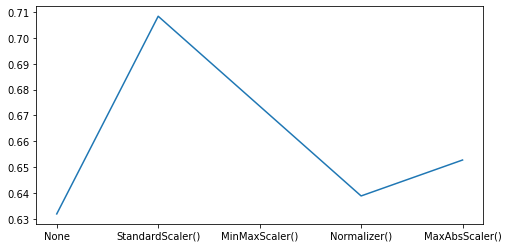

In [73]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 9.3 Tuning Parameter: n_neighbors and p

#### 9.3.1 Case 1: Standard Scaler

In [74]:
p_list = [1, 2, 3]
n_neighbors_lists = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [79]:
accuracy = []
x_ticks = []
for p in p_list:
    for n_neighbors in n_neighbors_lists:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', KNeighborsClassifier(
                p=p,
                n_neighbors=n_neighbors
            ))
        ])
        scores = cross_validate(pipe, X_train, y_train, cv=3)
        accuracy.append(np.mean(scores['test_score']))
        x_ticks.append(f'p={p}_n_neighbors={n_neighbors}')

Maximum accuracy for standard scaler is 0.736111111111111
Best model is p=1_n_neighbors=3


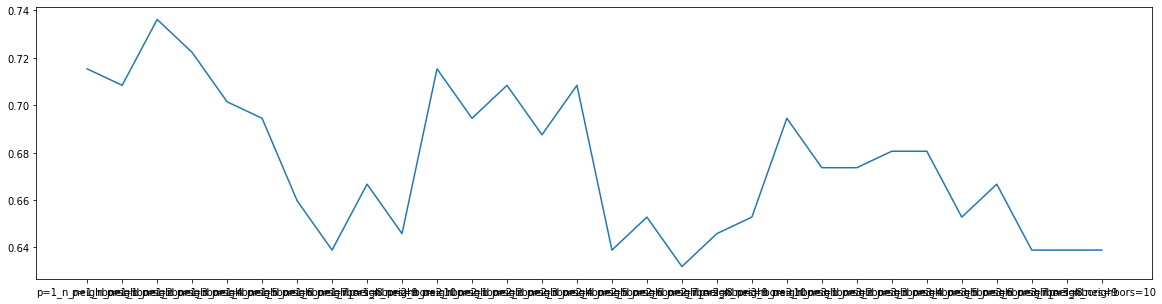

In [80]:
plot_params_accuracy(accuracy, x_ticks, height=5, width=20)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

In [82]:
pd.DataFrame({'setting': x_ticks, 'accuracy': accuracy}).sort_values('accuracy', ascending=False).head(n=5)

,setting,accuracy
2,p=1_n_neighbors=3,0.736111
3,p=1_n_neighbors=4,0.722222
0,p=1_n_neighbors=1,0.715278
10,p=2_n_neighbors=1,0.715278
1,p=1_n_neighbors=2,0.708333


The best parameter set for the standard scaler case is `p=1` and `n_neighbors=3`.

### 9.4 Validation Set

#### 9.4.1 Default Model

In [104]:
knn_predict_val = default_knn_classifier.predict(X_val)
print('Accuracy of CV training set KNN(default)):',
      np.mean(cross_validate(default_knn_classifier, X_train, y_train, cv=3)['test_score']))
print('Accuracy of Validation set KNN(default)):',
      metrics.accuracy_score(y_val, knn_predict_val))
print('F1 Score of Validation set KNN(default)):',
      metrics.f1_score(y_val, knn_predict_val, average='macro'))

Accuracy of CV training set KNN(default)): 0.6319444444444445
Accuracy of Validation set KNN(default)): 0.6216216216216216
F1 Score of Validation set KNN(default)): 0.3560224089635855


#### 9.4.2 Optimal Model

In [105]:
stanndard_optimal_knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(
        p=1,
        n_neighbors=3
    ))
])
stanndard_optimal_knn_pipe.fit(X_train, y_train)
scores = cross_validate(stanndard_optimal_knn_pipe, X_train, y_train, cv=3)
print('Optimal parameter training set score KNN (standard scaler):',
      np.mean(scores['test_score'])
)
optimal_knn_pipe_predict_val = stanndard_optimal_knn_pipe.predict(X_val)
print('Optimal parameter set score KNN (standard scaler) validation:',
      metrics.accuracy_score(y_val, optimal_knn_pipe_predict_val)
)
print('F1 Score of Validation set KNN (standard scaler)) validation:',
      metrics.f1_score(y_val, knn_predict_val, average='macro'))

Optimal parameter training set score KNN (standard scaler): 0.736111111111111
Optimal parameter set score KNN (standard scaler) validation: 0.6756756756756757
F1 Score of Validation set KNN (standard scaler)) validation: 0.3560224089635855


We could see that our model can beat the default model in term of accuracy but we could all see that the F1 score macro is the same. Our chosen parameters are `p=1` and `n_neighbors=3`.

## 10. Model#3 Random Forest

In [91]:
from sklearn.ensemble import RandomForestClassifier

### 10.1 The default Model

In [93]:
default_random_forest_classifier = RandomForestClassifier(random_state=RANDOM_SEED)
score = cross_validate(default_random_forest_classifier, X_train, y_train, cv=3)
print('Mean accuracy of Random Forest(default)) cv:', np.mean(score['test_score']))
default_random_forest_classifier.fit(X=X_train, y=y_train)

Mean accuracy of Random Forest(default)) cv: 0.7013888888888888


RandomForestClassifier(random_state=1234)

### 10.2 Parameter Scaling

In [94]:
pipe = Pipeline([
    ('scaler', None),
    ('classifier', RandomForestClassifier(random_state=RANDOM_SEED))
])
parameters = {'scaler': [None, StandardScaler(), MinMaxScaler(), Normalizer(), MaxAbsScaler()]}
grid = GridSearchCV(pipe, parameters, cv=3).fit(X_train, y_train)

We could see that for random forest we might not need any parameter scaling.

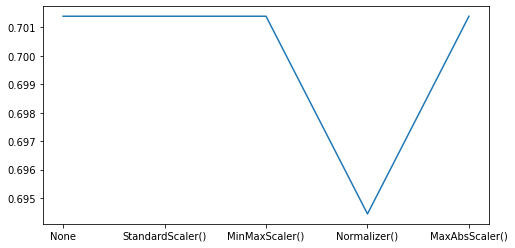

In [95]:
x_ticks = [str(p['scaler']) for p in grid.cv_results_['params']]
accuracy = grid.cv_results_['mean_test_score']
plot_params_accuracy(accuracy, x_ticks, 4, 8)

### 10.3 Tuning Parameter: criterion

In [96]:
accuracy = []
criterion_list = ['entropy', 'gini']
for criteria in criterion_list:
    random_forest_classifier = RandomForestClassifier(criterion=criteria, random_state=RANDOM_SEED)
    random_forest_model = random_forest_classifier.fit(X=X_train, y=y_train)
    predict_val = random_forest_model.predict(X_val)
    accuracy.append(metrics.accuracy_score(y_val, predict_val))

We could see that `entropy` work much better.

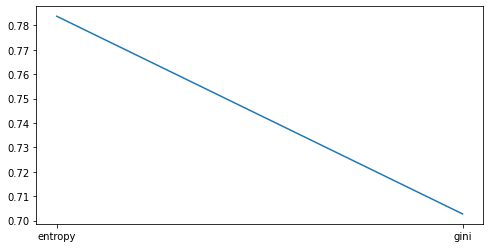

In [97]:
plot_params_accuracy(accuracy, criterion_list, 4, 8)

### 10.4 Tuning Parameter: n_estimators and max_depth

In [101]:
accuracy = []
n_estimator_list = [10, 50, 100, 300, 500, 1000, 3000, 10000]
max_depth_list = [3, 5, 10, 30, 100, 300, None]
x_ticks = []
for n_estimator in n_estimator_list:
    for max_depth in max_depth_list:
        random_forest_classifier = RandomForestClassifier(
            n_estimators=n_estimator, max_depth=max_depth, criterion=criteria, random_state=RANDOM_SEED
        )
        accuracy.append(np.mean(cross_validate(random_forest_classifier, X_train, y_train, cv=3, n_jobs=-1)['test_score']))
        x_ticks.append(f'n_estimator={n_estimator}_max_depth={max_depth}')

We could see that `n_estimator=500` and `max_depth=5` are the best parameter set.

Maximum accuracy for standard scaler is 0.736111111111111
Best model is n_estimator=3000_max_depth=10


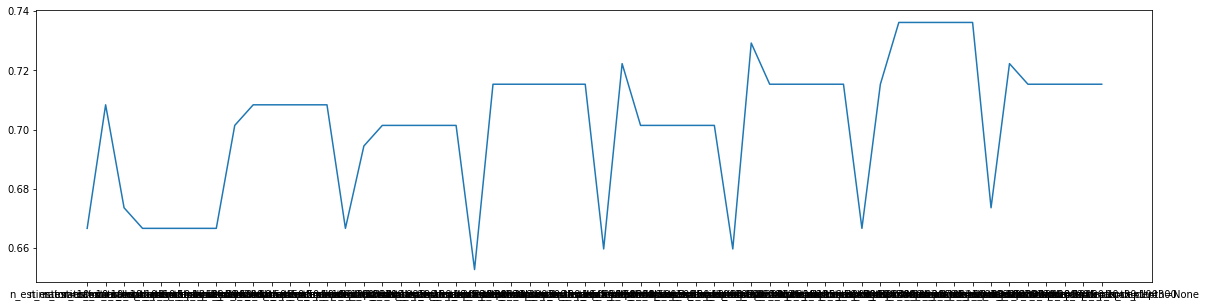

In [102]:
plot_params_accuracy(accuracy, x_ticks, height=5, width=20)
print('Maximum accuracy for standard scaler is', np.max(accuracy))
index = np.where(accuracy == np.amax(accuracy))
print(f'Best model is {x_ticks[index[0][0]]}')

In [103]:
pd.DataFrame({'setting': x_ticks, 'accuracy': accuracy}).sort_values('accuracy', ascending=False).head()

,setting,accuracy
44,n_estimator=3000_max_depth=10,0.736111
48,n_estimator=3000_max_depth=None,0.736111
47,n_estimator=3000_max_depth=300,0.736111
45,n_estimator=3000_max_depth=30,0.736111
46,n_estimator=3000_max_depth=100,0.736111


### 10.5 Validation Set

#### 10.5.1 Default Model

In [109]:
default_random_forest_val_predict = default_random_forest_classifier.predict(X_val)
metrics.accuracy_score(y_val, default_random_forest_val_predict)

print('Accuracy of CV training set Random Forest(default)):',
      np.mean(cross_validate(default_random_forest_classifier, X_train, y_train, cv=3)['test_score']))
print('Accuracy of Validation set Random Forest(default)):',
      metrics.accuracy_score(y_val, default_random_forest_val_predict))
print('F1 Score of Validation set Random Forest(default)):',
      metrics.f1_score(y_val, default_random_forest_val_predict, average='macro'))

Accuracy of CV training set Random Forest(default)): 0.7013888888888888
Accuracy of Validation set Random Forest(default)): 0.7027027027027027
F1 Score of Validation set Random Forest(default)): 0.5200779727095516


#### 10.5.2 Optimal Model

In [114]:
optimal_random_forest_classifier = RandomForestClassifier(
    n_estimators=3000, max_depth=10, criterion='entropy', random_state=RANDOM_SEED
)
optimal_random_forest_classifier.fit(X_train, y_train)
optimal_random_forest_val_predict = optimal_random_forest_classifier.predict(X_val)
metrics.accuracy_score(y_val, optimal_random_forest_val_predict)

print('Accuracy of CV training set Random Forest(optimal)):',
      np.mean(cross_validate(optimal_random_forest_classifier, X_train, y_train, cv=3)['test_score']))
print('Accuracy of Validation set Random Forest(optimal)):',
      metrics.accuracy_score(y_val, optimal_random_forest_val_predict))
print('F1 Score of Validation set Random Forest(optimal)):',
      metrics.f1_score(y_val, optimal_random_forest_val_predict, average='macro'))

Accuracy of CV training set Random Forest(optimal)): 0.701388888888889
Accuracy of Validation set Random Forest(optimal)): 0.7837837837837838
F1 Score of Validation set Random Forest(optimal)): 0.6789321789321789


We found that the optimal forest did a better job at predicting the validation set than the default model. Our chosen parameter are `n_estimators=3000`, ` max_depth=10`, `criterion='entropy'`

## Test Set Evaluation

Here we choose a model with the best parameters set from eash machine learning algorithms based on the validation set performance.

### Naive Baseline Model

In [119]:
most_occur_class = y_train.value_counts().idxmax()
baseline_predict_test = np.ones(len(y_test)) * most_occur_class
print(f'Accuracy of Baseline (predict with class {most_occur_class}) test set:',
      metrics.accuracy_score(y_test, baseline_predict_test))
print('F1 Score of Baseline test set:',
      metrics.f1_score(y_test, baseline_predict_test, average='macro'))

Accuracy of Baseline (predict with class 2) test set: 0.3333333333333333
F1 Score of Baseline test set: 0.08333333333333333


### Logistic Regression

In [120]:
final_optimal_logistic_regression_pipe = Pipeline([
    ('classifier', LogisticRegression(random_state=RANDOM_SEED,
                                      max_iter=10000,
                                      solver='liblinear',
                                      penalty='l2',
                                      C=10
                                     )
    )
])
final_optimal_logistic_regression_pipe.fit(X_model, y_model)
logistic_regression_predict_test = final_optimal_logistic_regression_pipe.predict(X_test)
print('Accuracy of test set Logistic Regression (optimal)):',
    metrics.accuracy_score(y_test, logistic_regression_predict_test))
print('F1 Score of test set Logistic Regression (optimal)):',
      metrics.f1_score(y_test, logistic_regression_predict_test, average='macro'))

Accuracy of test set Logistic Regression (optimal)): 0.696969696969697
F1 Score of test set Logistic Regression (optimal)): 0.5412698412698412


### K-Nearest Neighbor

In [121]:
final_min_max_optimal_knn_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', KNeighborsClassifier(
        p=1,
        n_neighbors=3
    ))
])
final_min_max_optimal_knn_pipe.fit(X_model, y_model)
knn_predict_test = final_min_max_optimal_knn_pipe.predict(X_test)
print('Accuracy of test set KNN (optimal)):',
      metrics.accuracy_score(y_test, knn_predict_test))
print('F1 Score of test set KNN (optimal)):',
      metrics.f1_score(y_test, knn_predict_test, average='macro'))

Accuracy of test set KNN (optimal)): 0.6666666666666666
F1 Score of test set KNN (optimal)): 0.6673202614379085


### Random Forest

In [128]:
optimal_random_forest_classifier = RandomForestClassifier(
    n_estimators=3000, max_depth=10, criterion='entropy', random_state=RANDOM_SEED
)
optimal_random_forest_classifier.fit(X_model, y_model)
optimal_random_forest_test_predict = optimal_random_forest_classifier.predict(X_test)
print('Accuracy of test set Random Forest (optimal)):',
      metrics.accuracy_score(y_test, optimal_random_forest_test_predict))
print('F1 Score of test set Random Forest (optimal)):',
      metrics.f1_score(y_test, optimal_random_forest_test_predict, average='macro'))

Accuracy of test set Random Forest (optimal)): 0.7878787878787878
F1 Score of test set Random Forest (optimal)): 0.7402597402597403


## Summary

We can see that the accuracy of each method aren't differ very much but the F1 score are significantly different. Here we can clearly choose the random forest as a final model.

The final parameter are `criterion='entropy'`, `n_estimator=3000` and `max_depth=10`